# Perbandingan Algoritma K-Means dan K-Medoids
## Pengelompokan Data Kemiskinan Kabupaten Pringsewu

**Prodi :** Teknik Informatika — Universitas Aisyah Pringsewu  

---
### Alur Notebook
| # | Tahap | Keterangan |
|---|-------|-----------|
| 1 | Import Library | Semua library yang dibutuhkan |
| 2 | Upload & Load Data | Upload file Excel dari komputer |
| 3 | Seleksi Kolom | Pilih kolom fitur sesuai proposal |
| 4 | Encoding | Ubah teks → angka (Label Encoding) |
| 5 | Cleaning | Tangani missing value & duplikat |
| 6 | K-Means | Iterasi lengkap + log |
| 7 | K-Medoids | Iterasi lengkap + cek penggantian medoid |
| 8 | Evaluasi | Silhouette Coefficient |
| 9 | Perhitungan Manual | Step-by-step untuk Bab 4 |
| 10 | Visualisasi | Scatter plot, silhouette plot, distribusi |
| 11 | Simpan CSV | Semua hasil tersimpan otomatis |
| 12 | Ringkasan | Perbandingan akhir K-Means vs K-Medoids |


---
## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import math, os, io, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

print("✓ Semua library berhasil diimport")
print(f"  Pandas  : {pd.__version__}")
print(f"  NumPy   : {np.__version__}")


✓ Semua library berhasil diimport
  Pandas  : 2.2.2
  NumPy   : 2.0.2


---
## 2. Upload & Load Data

> Klik tombol **Choose Files**, pilih file **Data_Kemiskinan.xlsx** dari komputer kamu.

In [2]:
from google.colab import files

print("Klik 'Choose Files' lalu pilih file Excel kamu.")
uploaded = files.upload()

nama_file = list(uploaded.keys())[0]
ekstensi  = nama_file.split('.')[-1].lower()

if ekstensi in ['xlsx','xls']:
    df_raw = pd.read_excel(io.BytesIO(uploaded[nama_file]), header=None)
else:
    df_raw = pd.read_csv(io.BytesIO(uploaded[nama_file]), header=None)

print(f"\n✓ File dimuat: {nama_file}")
print(f"  Ukuran    : {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom")
df_raw.head(10)


Klik 'Choose Files' lalu pilih file Excel kamu.


Saving Data Kemiskinan.xlsx to Data Kemiskinan.xlsx

✓ File dimuat: Data Kemiskinan.xlsx
  Ukuran    : 734 baris × 28 kolom


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NO,ID P3KE,NAMA,NIK,KK,KECAMATAN,PEKON/KELURAHAN,ALAMAT,RT,RW,...,Kualitas Atap,Jenis Dinding,Kualitas Dinding,Jenis Lantai,Kualitas Lantai,Sumber Penerangan,Daya Listrik Terpasang,Bahan Bakar Memasak,Sumber Air Minum,Memiliki fasilitas Buang Air Besar
3,1,193670169,HENDRA HARIYANTO,1810071606930000,1810073108200000,ADILUWIH,ADILUWIH,ADILUWIH,13,3,...,Jelek/Kualitas Rendah,Bambu,Jelek/Kualitas Rendah,Tanah,Jelek/Kualitas Rendah,Listrik PLN meteran,=< 900 watt,Listrik/Gas,Sumur Terlindung,Lainnya
4,2,193670189,CICUK,1810070107640090,1810071706100030,ADILUWIH,ADILUWIH,ADILUWIH,13,3,...,Bagus/Kualitas Tinggi,Tembok,Bagus/Kualitas Tinggi,Tanah,Bagus/Kualitas Tinggi,Listrik PLN meteran,=< 900 watt,Arang/Kayu,Sumur Terlindung,Lainnya
5,3,193670270,KATIJAH,1810075709650000,1810070110180000,ADILUWIH,ADILUWIH,ADILUWIH,14,3,...,Bagus/Kualitas Tinggi,Tembok,Bagus/Kualitas Tinggi,Semen,Bagus/Kualitas Tinggi,Listrik PLN meteran,=< 900 watt,Arang/Kayu,Sumur Terlindung,Lainnya
6,4,137941230,PARWOTO,1810070902750000,1810070609100090,ADILUWIH,BANDUNG BARU,BANDUNG BARU,5,2,...,NaN,Kayu/Papan,NaN,Semen,NaN,Listrik Pribadi s/d 900 Watt,NaN,Listrik/Gas,Sumur Terlindung,"Ya, tanpa Septic Tank"
7,5,193668738,SUTARTU,1810070107840060,1810073110190000,ADILUWIH,BANDUNG BARU,BANDUNG BARU,1,1,...,Bagus/Kualitas Tinggi,Tembok,Bagus/Kualitas Tinggi,Semen,Bagus/Kualitas Tinggi,Listrik PLN meteran,=< 900 watt,Listrik/Gas,Sumur Terlindung,Milik sendiri
8,6,193669087,AHYADI,1571080205760020,1810072111190000,ADILUWIH,BANDUNG BARU,BANDUNG BARU,8,3,...,Jelek/Kualitas Rendah,Kayu/Papan,Jelek/Kualitas Rendah,Semen,Jelek/Kualitas Rendah,Listrik PLN meteran,=< 900 watt,Listrik/Gas,Sumur Terlindung,Lainnya
9,7,193669928,NURHADI,1810071709880000,1810072906160000,ADILUWIH,BANDUNG BARU,BANDUNG BARU,20,7,...,Jelek/Kualitas Rendah,Bambu,Jelek/Kualitas Rendah,Semen,Jelek/Kualitas Rendah,Listrik PLN meteran,=< 900 watt,Arang/Kayu,Sumur Tidak Terlindung,Milik sendiri


---
## 3. Seleksi Kolom Fitur

Berdasarkan proposal, kolom yang digunakan untuk clustering adalah:

| Kolom Excel | Nama Variabel | Keterangan |
|-------------|--------------|-----------|
| Unnamed: 14 | PEKERJAAN | Jenis pekerjaan kepala keluarga |
| Unnamed: 15 | KEPEMILIKAN_RUMAH | Status kepemilikan rumah |
| Unnamed: 17 | JENIS_ATAP | Material atap rumah |
| Unnamed: 19 | JENIS_DINDING | Material dinding rumah |
| Unnamed: 21 | JENIS_LANTAI | Material lantai rumah |
| Unnamed: 24 | DAYA_LISTRIK | Daya listrik terpasang |
| Unnamed: 25 | BAHAN_BAKAR | Bahan bakar memasak |
| Unnamed: 26 | SUMBER_AIR | Sumber air minum |
| Unnamed: 27 | FASILITAS_BAB | Fasilitas buang air besar |


In [3]:
import pandas as pd
import io

# Re-read the original file content to ensure df_raw is always fresh
nama_file = list(uploaded.keys())[0]
ekstensi  = nama_file.split('.')[-1].lower()

if ekstensi in ['xlsx','xls']:
    df_raw_original = pd.read_excel(io.BytesIO(uploaded[nama_file]), header=None)
else:
    df_raw_original = pd.read_csv(io.BytesIO(uploaded[nama_file]), header=None)

# Ambil baris header (baris ketiga berisi nama kolom) dari df_raw asli
header_values = df_raw_original.iloc[2].astype(str).str.strip().tolist()

# Buat DataFrame baru dengan data mulai dari baris ke-4 (indeks 3) dan reset indeks
df_clean_raw = df_raw_original.iloc[3:].copy()
df_clean_raw.columns = header_values # Tetapkan nilai header sebagai nama kolom
df_clean_raw.reset_index(drop=True, inplace=True)

# Peta kolom asli → nama variabel yang dipakai
KOLOM_MAP = {
    'PEKERJAAN'         : 'PEKERJAAN',
    'Kepemilikan Rumah' : 'KEPEMILIKAN_RUMAH',
    'Jenis Atap'        : 'JENIS_ATAP',
    'Jenis Dinding'     : 'JENIS_DINDING',
    'Jenis Lantai'      : 'JENIS_LANTAI',
    'Daya Listrik Terpasang' : 'DAYA_LISTRIK',
    'Bahan Bakar Memasak'    : 'BAHAN_BAKAR',
    'Sumber Air Minum'  : 'SUMBER_AIR',
    'Memiliki fasilitas Buang Air Besar' : 'FASILITAS_BAB',
}

# Filter kolom yang ada di dataframe `df_clean_raw` yang baru
kolom_ada = {k:v for k,v in KOLOM_MAP.items() if k in df_clean_raw.columns}
kolom_hilang = [k for k in KOLOM_MAP if k not in df_clean_raw.columns]
if kolom_hilang:
    print(f"[!] Kolom tidak ditemukan: {kolom_hilang}")

df_fitur = df_clean_raw[list(kolom_ada.keys())].copy()
df_fitur.rename(columns=kolom_ada, inplace=True)

print(f"✓ Kolom fitur dipilih: {list(df_fitur.columns)}")
print(f"  Jumlah data: {len(df_fitur)} baris")
print()
df_fitur.head(5)

✓ Kolom fitur dipilih: ['PEKERJAAN', 'KEPEMILIKAN_RUMAH', 'JENIS_ATAP', 'JENIS_DINDING', 'JENIS_LANTAI', 'DAYA_LISTRIK', 'BAHAN_BAKAR', 'SUMBER_AIR', 'FASILITAS_BAB']
  Jumlah data: 731 baris



,PEKERJAAN,KEPEMILIKAN_RUMAH,JENIS_ATAP,JENIS_DINDING,JENIS_LANTAI,DAYA_LISTRIK,BAHAN_BAKAR,SUMBER_AIR,FASILITAS_BAB
0,Tidak/Belum Bekerja,Bebas Sewa/Menumpang,Genteng,Bambu,Tanah,=< 900 watt,Listrik/Gas,Sumur Terlindung,Lainnya
1,Petani,Milik Sendiri,Genteng,Tembok,Tanah,=< 900 watt,Arang/Kayu,Sumur Terlindung,Lainnya
2,Tidak/Belum Bekerja,Milik Sendiri,Genteng,Tembok,Semen,=< 900 watt,Arang/Kayu,Sumur Terlindung,Lainnya
3,PETANI/PEKEBUN,Milik Sendiri,Genteng,Kayu/Papan,Semen,NaN,Listrik/Gas,Sumur Terlindung,"Ya, tanpa Septic Tank"
4,BURUH HARIAN LEPAS,Milik Sendiri,Genteng,Tembok,Semen,=< 900 watt,Listrik/Gas,Sumur Terlindung,Milik sendiri


---
## 4. Data Cleaning

Hapus header palsu, tangani missing value, dan hapus duplikat.

In [4]:
OUTPUT_DIR = '/content/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_cleaned_pre_enc = df_fitur.copy()

# Treat 'nan', 'NaN', 'None', '' as actual NaN values for cleaning
for col in df_cleaned_pre_enc.columns:
    df_cleaned_pre_enc[col] = df_cleaned_pre_enc[col].replace(['nan', 'NaN', 'None', ''], np.nan)

# Hapus baris yang masih berisi teks header (gagal di-encode → NaN semua)
df_cleaned_pre_enc.dropna(how='all', inplace=True)

# Isi missing value dengan modus tiap kolom (for object/string columns)
for col in df_cleaned_pre_enc.columns:
    if df_cleaned_pre_enc[col].isnull().any():
        modus = df_cleaned_pre_enc[col].mode()
        fill  = modus[0] if not modus.empty else 'UNDEFINED' # Fallback for strings
        df_cleaned_pre_enc[col].fillna(fill, inplace=True)
        print(f"  [!] {col}: {df_cleaned_pre_enc[col].isnull().sum()} missing → diisi modus = '{fill}'")

# Hapus duplikat
sebelum = len(df_cleaned_pre_enc)
df_cleaned_pre_enc.drop_duplicates(inplace=True)
df_cleaned_pre_enc.reset_index(drop=True, inplace=True)
sesudah = len(df_cleaned_pre_enc)

print(f"\n✓ Data bersih (sebelum encoding) : {sesudah} baris ({sebelum - sesudah} duplikat dihapus)")
print(f"  Kolom       : {list(df_cleaned_pre_enc.columns)}")

# Simpan hasil cleaning sebelum encoding
df_cleaned_pre_enc.to_csv(f'{OUTPUT_DIR}/00_data_setelah_cleaning_sebelum_encoding.csv', index=False)
print(f"  Disimpan ke : {OUTPUT_DIR}/00_data_setelah_cleaning_sebelum_encoding.csv")

df_cleaned_pre_enc.head(5)

  [!] DAYA_LISTRIK: 0 missing → diisi modus = '=< 900 watt'

✓ Data bersih (sebelum encoding) : 517 baris (214 duplikat dihapus)
  Kolom       : ['PEKERJAAN', 'KEPEMILIKAN_RUMAH', 'JENIS_ATAP', 'JENIS_DINDING', 'JENIS_LANTAI', 'DAYA_LISTRIK', 'BAHAN_BAKAR', 'SUMBER_AIR', 'FASILITAS_BAB']
  Disimpan ke : /content/output/00_data_setelah_cleaning_sebelum_encoding.csv


,PEKERJAAN,KEPEMILIKAN_RUMAH,JENIS_ATAP,JENIS_DINDING,JENIS_LANTAI,DAYA_LISTRIK,BAHAN_BAKAR,SUMBER_AIR,FASILITAS_BAB
0,Tidak/Belum Bekerja,Bebas Sewa/Menumpang,Genteng,Bambu,Tanah,=< 900 watt,Listrik/Gas,Sumur Terlindung,Lainnya
1,Petani,Milik Sendiri,Genteng,Tembok,Tanah,=< 900 watt,Arang/Kayu,Sumur Terlindung,Lainnya
2,Tidak/Belum Bekerja,Milik Sendiri,Genteng,Tembok,Semen,=< 900 watt,Arang/Kayu,Sumur Terlindung,Lainnya
3,PETANI/PEKEBUN,Milik Sendiri,Genteng,Kayu/Papan,Semen,=< 900 watt,Listrik/Gas,Sumur Terlindung,"Ya, tanpa Septic Tank"
4,BURUH HARIAN LEPAS,Milik Sendiri,Genteng,Tembok,Semen,=< 900 watt,Listrik/Gas,Sumur Terlindung,Milik sendiri


---
## 5. Encoding — Ubah Teks ke Angka

Setiap nilai teks diubah ke angka ordinal sesuai tingkat kualitas.  
Semakin tinggi angka = semakin baik/layak kondisinya.


In [5]:
# ══════════════════════════════════════════════════════════
# ENCODING MAP — sesuai nilai asli di file Excel
# ══════════════════════════════════════════════════════════
ENCODING_MAP = {
    'PEKERJAAN': {
        'BELUM/TIDAK BEKERJA'   : 0,
        'Tidak/Belum Bekerja'   : 0,
        'MENGURUS RUMAH TANGGA' : 1,
        'BURUH HARIAN LEPAS'    : 2,
        'BURUH TANI/PERKEBUNAN' : 2,
        'PEKERJA LEPAS'         : 2,
        'TUKANG KAYU'           : 3,
        'PENJAHIT'              : 3,
        'PETANI/PEKEBUN'        : 3,
        'Petani'                : 3,
        'PEDAGANG'              : 4,
        'WIRASWASTA'            : 5,
        'KARYAWAN SWASTA'       : 6,
        'PELAJAR/MAHASISWA'     : 7,
    },
    'KEPEMILIKAN_RUMAH': {
        'Lainnya'               : 0,
        'Bebas Sewa'            : 1,
        'Bebas Sewa/Menumpang'  : 1,
        'Menumpang'             : 1,
        'Kontrak/Sewa'          : 2,
        'Milik Sendiri'         : 3,
    },
    'JENIS_ATAP': {
        'Jerami/Ijuk/Rumbia/Daun-daunan' : 0,
        'Bambu'                           : 1,
        'Asbes/Seng'                      : 2,
        'Genteng'                         : 3,
    },
    'JENIS_DINDING': {
        'Lainnya'    : 0,
        'Bambu'      : 1,
        'Kayu/Papan' : 2,
        'Tembok'     : 3,
    },
    'JENIS_LANTAI': {
        'Lainnya'                                    : 0,
        'Bambu'                                      : 1,
        'Tanah'                                      : 2,
        'Kayu/Papan'                                 : 3,
        'Semen'                                      : 4,
        'Keramik/Granit/Marmer/Ubin/Tegel/Teraso'   : 5,
    },
    'DAYA_LISTRIK': {
        'Kosong'               : 0,
        '=< 900 watt'          : 1,
        '> 900 watt'           : 2,
    },
    'BAHAN_BAKAR': {
        'Arang/Kayu'    : 0,
        'Lainnya'       : 1,
        'Listrik/Gas'   : 2,
    },
    'SUMBER_AIR': {
        'Air Permukaan (Sungai, Danau, dll)' : 0,
        'Air Hujan'                           : 1,
        'Lainnya'                             : 2,
        'Sumur Tidak Terlindung'              : 3,
        'Sumur Terlindung'                    : 4,
        'Sumur Bor'                           : 4,
        'Air Kemasan/Isi Ulang'              : 5,
        'Ledeng/PAM'                          : 5,
    },
    'FASILITAS_BAB': {
        'Kosong'                              : 0,
        'Tidak, Jamban Umum/Bersama'          : 1,
        'Umum/Bersama'                        : 1,
        'Lainnya'                             : 2,
        'Ya, tanpa Septic Tank'               : 3,
        'Milik sendiri'                       : 4,
        'Ya, dengan Septic Tank'              : 4,
    },
}

# ── Terapkan encoding ──
# Input for encoding is now df_cleaned_pre_enc
df_enc = df_cleaned_pre_enc.copy()
log_enc = []

for kolom, mapping in ENCODING_MAP.items():
    if kolom not in df_enc.columns:
        continue

    # Strip spasi
    df_enc[kolom] = df_enc[kolom].astype(str).str.strip()

    # Deteksi nilai yang tidak ada di mapping
    nilai_unik    = df_enc[kolom].unique()
    tidak_dikenal = [v for v in nilai_unik if v not in mapping
                     and v not in ['nan','NaN','None','','PEKERJAAN',
                                   'Kepemilikan Rumah','Jenis Atap','Jenis Dinding',
                                   'Jenis Lantai','Daya Listrik Terpasang',
                                   'Bahan Bakar Memasak','Sumber Air Minum',
                                   'Memiliki fasilitas Buang Air Besar']]
    if tidak_dikenal:
        print(f"  [!] {kolom}: nilai belum di-mapping → {tidak_dikenal}")
        maks = max(mapping.values()) + 1
        for v in tidak_dikenal:
            mapping[v] = maks
            maks += 1

    df_enc[kolom] = df_enc[kolom].map(mapping)
    print(f"  ✓ {kolom}: {dict(sorted(mapping.items(), key=lambda x: x[1]))}")
    log_enc.append({'Kolom': kolom, 'Status': 'Di-encode', 'Jumlah Nilai': len(mapping)})

# Convert all columns to numeric, coercing errors, then fill NaNs and convert to int
for col in df_enc.columns:
    df_enc[col] = pd.to_numeric(df_enc[col], errors='coerce')
    if df_enc[col].isnull().any():
        modus = df_enc[col].mode()
        fill  = modus[0] if not modus.empty else 0
        df_enc[col].fillna(fill, inplace=True)
        print(f"  [!] {col}: {df_enc[col].isnull().sum()} missing (after encoding) → diisi modus = {fill}")

df_enc = df_enc.astype(int)

print("\n=== Preview setelah encoding ===")
print(df_enc.head(5).to_string())
print("✓ Encoding step re-executed.")

# Simpan
df_enc.to_csv(f'{OUTPUT_DIR}/01_data_setelah_encoding.csv', index=False)
print(f"  Disimpan ke : {OUTPUT_DIR}/01_data_setelah_encoding.csv")

  ✓ PEKERJAAN: {'BELUM/TIDAK BEKERJA': 0, 'Tidak/Belum Bekerja': 0, 'MENGURUS RUMAH TANGGA': 1, 'BURUH HARIAN LEPAS': 2, 'BURUH TANI/PERKEBUNAN': 2, 'PEKERJA LEPAS': 2, 'TUKANG KAYU': 3, 'PENJAHIT': 3, 'PETANI/PEKEBUN': 3, 'Petani': 3, 'PEDAGANG': 4, 'WIRASWASTA': 5, 'KARYAWAN SWASTA': 6, 'PELAJAR/MAHASISWA': 7}
  ✓ KEPEMILIKAN_RUMAH: {'Lainnya': 0, 'Bebas Sewa': 1, 'Bebas Sewa/Menumpang': 1, 'Menumpang': 1, 'Kontrak/Sewa': 2, 'Milik Sendiri': 3}
  ✓ JENIS_ATAP: {'Jerami/Ijuk/Rumbia/Daun-daunan': 0, 'Bambu': 1, 'Asbes/Seng': 2, 'Genteng': 3}
  ✓ JENIS_DINDING: {'Lainnya': 0, 'Bambu': 1, 'Kayu/Papan': 2, 'Tembok': 3}
  ✓ JENIS_LANTAI: {'Lainnya': 0, 'Bambu': 1, 'Tanah': 2, 'Kayu/Papan': 3, 'Semen': 4, 'Keramik/Granit/Marmer/Ubin/Tegel/Teraso': 5}
  ✓ DAYA_LISTRIK: {'Kosong': 0, '=< 900 watt': 1, '> 900 watt': 2}
  ✓ BAHAN_BAKAR: {'Arang/Kayu': 0, 'Lainnya': 1, 'Listrik/Gas': 2}
  ✓ SUMBER_AIR: {'Air Permukaan (Sungai, Danau, dll)': 0, 'Air Hujan': 1, 'Lainnya': 2, 'Sumur Tidak Terlindun

---
## 6. Konfigurasi Clustering


In [6]:
K_CLUSTER   = 3    # jumlah cluster — ubah sesuai kebutuhan
MAX_ITER    = 100  # batas iterasi
RANDOM_SEED = 42

KOLOM_FITUR = list(df_enc.columns) # Use df_enc as it's the final encoded data
X   = df_enc[KOLOM_FITUR].values.tolist()
n   = len(X)
d   = len(X[0])

print(f"Jumlah data  : {n}")
print(f"Jumlah fitur : {d}  → {KOLOM_FITUR}")
print(f"k            : {K_CLUSTER}")

Jumlah data  : 517
Jumlah fitur : 9  → ['PEKERJAAN', 'KEPEMILIKAN_RUMAH', 'JENIS_ATAP', 'JENIS_DINDING', 'JENIS_LANTAI', 'DAYA_LISTRIK', 'BAHAN_BAKAR', 'SUMBER_AIR', 'FASILITAS_BAB']
k            : 3


---
## 7. Fungsi Pendukung


In [7]:
def euclidean(a, b):
    """Jarak Euclidean: D = sqrt(sum((ai-bi)^2))"""
    return math.sqrt(sum((ai-bi)**2 for ai,bi in zip(a,b)))

def interpretasi_silhouette(s):
    if s >= 0.71: return "Struktur cluster kuat"
    if s >= 0.51: return "Struktur cluster cukup baik"
    if s >= 0.26: return "Struktur cluster lemah"
    return "Tidak ada struktur cluster yang nyata"

print("✓ Fungsi pendukung siap")

# Demo
a, b = X[0], X[1]
print(f"  Contoh jarak D1→D2 = {euclidean(a,b):.6f}")


✓ Fungsi pendukung siap
  Contoh jarak D1→D2 = 4.582576


---
## 8. Algoritma K-Means

**Langkah:**
1. Pilih centroid awal secara acak
2. Hitung jarak Euclidean tiap data ke semua centroid
3. Assign data ke centroid terdekat
4. Update centroid = rata-rata anggota cluster
5. Ulangi sampai tidak ada perubahan (konvergen)


In [8]:
def kmeans(X, k, max_iter=MAX_ITER, seed=RANDOM_SEED):
    np.random.seed(seed)
    n = len(X)
    idx_awal  = np.random.choice(n, k, replace=False).tolist()
    centroids = [X[i][:] for i in idx_awal]
    labels    = [0] * n
    log       = []

    print(f"Centroid awal (indeks data): {idx_awal}")
    for ci, c in enumerate(centroids):
        print(f"  C{ci+1} = {c}")
    print()

    for it in range(1, max_iter+1):
        # Hitung jarak & assign
        jarak_mat  = [[euclidean(xi, c) for c in centroids] for xi in X]
        labels_baru= [row.index(min(row)) for row in jarak_mat]

        # Update centroid
        centroids_baru = []
        for ci in range(k):
            anggota = [X[j] for j in range(n) if labels_baru[j]==ci]
            centroids_baru.append(
                [sum(col)/len(col) for col in zip(*anggota)] if anggota
                else centroids[ci][:]
            )

        perubahan = sum(euclidean(centroids[ci], centroids_baru[ci]) for ci in range(k))
        konvergen = (labels_baru == labels and perubahan < 1e-6)
        log.append({'Iterasi': it,
                    'Perubahan Centroid': round(perubahan,6),
                    'Anggota': str([labels_baru.count(ci) for ci in range(k)]),
                    'Konvergen': 'Ya' if konvergen else 'Tidak'})
        print(f"  Iter {it:3d} | Δcentroid={perubahan:.6f} | "
              f"Anggota={[labels_baru.count(ci) for ci in range(k)]}")
        labels    = labels_baru
        centroids = centroids_baru
        if konvergen:
            print(f"\n✓ K-Means konvergen di iterasi {it}")
            break

    return labels, centroids, jarak_mat, log

print("=== Menjalankan K-Means ===")
labels_km, centroids_km, jarak_km, log_km = kmeans(X, K_CLUSTER)


=== Menjalankan K-Means ===
Centroid awal (indeks data): [304, 501, 441]
  C1 = [1, 3, 3, 2, 4, 1, 0, 0, 4]
  C2 = [5, 3, 3, 2, 5, 1, 0, 3, 4]
  C3 = [3, 3, 3, 3, 2, 1, 2, 3, 4]

  Iter   1 | Δcentroid=6.627755 | Anggota=[35, 85, 397]
  Iter   2 | Δcentroid=1.537785 | Anggota=[40, 122, 355]
  Iter   3 | Δcentroid=0.681330 | Anggota=[44, 139, 334]
  Iter   4 | Δcentroid=0.692113 | Anggota=[52, 158, 307]
  Iter   5 | Δcentroid=0.921729 | Anggota=[65, 189, 263]
  Iter   6 | Δcentroid=0.763691 | Anggota=[84, 206, 227]
  Iter   7 | Δcentroid=0.926322 | Anggota=[108, 221, 188]
  Iter   8 | Δcentroid=0.932956 | Anggota=[121, 227, 169]
  Iter   9 | Δcentroid=0.517765 | Anggota=[119, 231, 167]
  Iter  10 | Δcentroid=0.274824 | Anggota=[125, 229, 163]
  Iter  11 | Δcentroid=0.102625 | Anggota=[128, 227, 162]
  Iter  12 | Δcentroid=0.000000 | Anggota=[128, 227, 162]

✓ K-Means konvergen di iterasi 12


### Hasil Cluster K-Means


In [9]:
print("=== Hasil Cluster K-Means ===")
# km_label_map tersedia setelah cell interpretasi — tampilkan setelah itu
# Tampilan sementara pakai nomor cluster (akan ditampilkan ulang di cell interpretasi)
for ci in range(K_CLUSTER):
    anggota = [i for i,l in enumerate(labels_km) if l==ci]
    print(f"  Cluster {ci+1}: {len(anggota):4d} data | "
          f"Centroid = {[round(v,3) for v in centroids_km[ci]]}")

pd.DataFrame(log_km)


=== Hasil Cluster K-Means ===
  Cluster 1:  128 data | Centroid = [2.43, 2.289, 2.969, 1.922, 2.797, 0.742, 1.203, 3.508, 1.156]
  Cluster 2:  227 data | Centroid = [2.639, 2.361, 2.943, 1.996, 4.018, 0.921, 1.529, 3.907, 3.965]
  Cluster 3:  162 data | Centroid = [2.537, 2.414, 2.926, 1.994, 1.938, 0.796, 1.259, 3.877, 3.889]


,Iterasi,Perubahan Centroid,Anggota,Konvergen
0,1,6.627755,"[35, 85, 397]",Tidak
1,2,1.537785,"[40, 122, 355]",Tidak
2,3,0.681330,"[44, 139, 334]",Tidak
3,4,0.692113,"[52, 158, 307]",Tidak
4,5,0.921729,"[65, 189, 263]",Tidak
5,6,0.763691,"[84, 206, 227]",Tidak
6,7,0.926322,"[108, 221, 188]",Tidak
7,8,0.932956,"[121, 227, 169]",Tidak
8,9,0.517765,"[119, 231, 167]",Tidak
9,10,0.274824,"[125, 229, 163]",Tidak


---
## 9. Algoritma K-Medoids (PAM)

**Perbedaan utama dari K-Means:**  
Medoid harus berupa **data asli** dalam dataset (bukan rata-rata).  
Penggantian medoid dilakukan jika total biaya (total jarak) berkurang.


In [10]:
def kmedoids(X, k, max_iter=MAX_ITER, seed=RANDOM_SEED):
    np.random.seed(seed)
    n = len(X)

    # Hitung distance matrix sekali
    dist = [[0.0]*n for _ in range(n)]
    for i in range(n):
        for j in range(i+1,n):
            d = euclidean(X[i],X[j])
            dist[i][j] = d; dist[j][i] = d

    medoids = sorted(np.random.choice(n,k,replace=False).tolist())
    log     = []

    print(f"Medoid awal (indeks): {medoids}")
    for ci,m in enumerate(medoids):
        print(f"  M{ci+1} = indeks {m}: {X[m]}")
    print()

    for it in range(1, max_iter+1):
        # Assign cluster
        labels = [min(range(k), key=lambda ci: dist[i][medoids[ci]]) for i in range(n)]
        biaya  = sum(dist[i][medoids[labels[i]]] for i in range(n))

        # Cek ganti medoid
        medoids_baru  = medoids[:]
        ada_perubahan = False
        for ci in range(k):
            anggota       = [j for j in range(n) if labels[j]==ci]
            best_biaya    = biaya
            best_medoid   = medoids[ci]
            for kandidat in anggota:
                if kandidat == medoids[ci]: continue
                med_coba  = medoids[:]
                med_coba[ci] = kandidat
                b_coba    = sum(min(dist[i][m] for m in med_coba) for i in range(n))
                if b_coba < best_biaya:
                    best_biaya  = b_coba
                    best_medoid = kandidat
                    ada_perubahan = True
            medoids_baru[ci] = best_medoid

        log.append({'Iterasi': it,
                    'Total Biaya': round(biaya,4),
                    'Medoid': str(medoids),
                    'Anggota': str([labels.count(ci) for ci in range(k)]),
                    'Konvergen': 'Ya' if not ada_perubahan else 'Tidak'})
        print(f"  Iter {it:3d} | Biaya={biaya:.4f} | "
              f"Anggota={[labels.count(ci) for ci in range(k)]}")

        if not ada_perubahan:
            print(f"\n✓ K-Medoids konvergen di iterasi {it}")
            break
        medoids = medoids_baru

    # Final assign
    jarak_mat    = [[dist[i][m] for m in medoids] for i in range(n)]
    labels_final = [row.index(min(row)) for row in jarak_mat]
    return labels_final, medoids, jarak_mat, log

print("=== Menjalankan K-Medoids ===")
labels_kmed, medoid_idx, jarak_kmed, log_kmed = kmedoids(X, K_CLUSTER)


=== Menjalankan K-Medoids ===
Medoid awal (indeks): [304, 441, 501]
  M1 = indeks 304: [1, 3, 3, 2, 4, 1, 0, 0, 4]
  M2 = indeks 441: [3, 3, 3, 3, 2, 1, 2, 3, 4]
  M3 = indeks 501: [5, 3, 3, 2, 5, 1, 0, 3, 4]

  Iter   1 | Biaya=1646.0022 | Anggota=[35, 409, 73]
  Iter   2 | Biaya=1348.7090 | Anggota=[84, 344, 89]
  Iter   3 | Biaya=1275.0897 | Anggota=[131, 285, 101]
  Iter   4 | Biaya=1269.7454 | Anggota=[114, 317, 86]
  Iter   5 | Biaya=1272.3066 | Anggota=[132, 283, 102]
  Iter   6 | Biaya=1270.2440 | Anggota=[136, 298, 83]
  Iter   7 | Biaya=1280.1415 | Anggota=[122, 264, 131]
  Iter   8 | Biaya=1283.8580 | Anggota=[117, 272, 128]
  Iter   9 | Biaya=1327.8091 | Anggota=[120, 272, 125]
  Iter  10 | Biaya=1270.2440 | Anggota=[136, 298, 83]
  Iter  11 | Biaya=1280.1415 | Anggota=[122, 264, 131]
  Iter  12 | Biaya=1283.8580 | Anggota=[117, 272, 128]
  Iter  13 | Biaya=1327.8091 | Anggota=[120, 272, 125]
  Iter  14 | Biaya=1270.2440 | Anggota=[136, 298, 83]
  Iter  15 | Biaya=1280.1415

### Hasil Cluster K-Medoids


In [11]:
print("=== Hasil Cluster K-Medoids ===")
for ci in range(K_CLUSTER):
    anggota = [i for i,l in enumerate(labels_kmed) if l==ci]
    print(f"  Cluster {ci+1}: {len(anggota):4d} data | "
          f"Medoid = indeks {medoid_idx[ci]}: {X[medoid_idx[ci]]}")

pd.DataFrame(log_kmed)


=== Hasil Cluster K-Medoids ===
  Cluster 1:  120 data | Medoid = indeks 146: [3, 3, 3, 2, 2, 1, 0, 4, 4]
  Cluster 2:  272 data | Medoid = indeks 24: [3, 3, 3, 2, 3, 1, 2, 4, 4]
  Cluster 3:  125 data | Medoid = indeks 406: [3, 3, 3, 2, 2, 1, 2, 4, 3]


,Iterasi,Total Biaya,Medoid,Anggota,Konvergen
0,1,1646.0022,"[304, 441, 501]","[35, 409, 73]",Tidak
1,2,1348.7090,"[266, 24, 356]","[84, 344, 89]",Tidak
2,3,1275.0897,"[357, 24, 330]","[131, 285, 101]",Tidak
3,4,1269.7454,"[63, 24, 445]","[114, 317, 86]",Tidak
4,5,1272.3066,"[146, 24, 109]","[132, 283, 102]",Tidak
...,...,...,...,...,...
95,96,1283.8580,"[74, 79, 445]","[117, 272, 128]",Tidak
96,97,1327.8091,"[146, 24, 406]","[120, 272, 125]",Tidak
97,98,1270.2440,"[63, 79, 445]","[136, 298, 83]",Tidak
98,99,1280.1415,"[146, 24, 326]","[122, 264, 131]",Tidak


---
## 10. Evaluasi — Silhouette Coefficient

**Rentang nilai:** -1 hingga 1  
- ≥ 0.71 → Kuat | 0.51–0.70 → Cukup baik | 0.26–0.50 → Lemah | < 0.26 → Tidak ada struktur


In [12]:
X_np         = np.array(X)
sil_km       = silhouette_score(X_np, labels_km)
sil_kmed     = silhouette_score(X_np, labels_kmed)
sil_samp_km  = silhouette_samples(X_np, labels_km)
sil_samp_kmed= silhouette_samples(X_np, labels_kmed)

print("=" * 60)
print(f"  K-Means   | Silhouette = {sil_km:.4f} | {interpretasi_silhouette(sil_km)}")
print(f"  K-Medoids | Silhouette = {sil_kmed:.4f} | {interpretasi_silhouette(sil_kmed)}")
print("=" * 60)
print(f"  ► Metode terbaik : {'K-Means' if sil_km >= sil_kmed else 'K-Medoids'}")
print("=" * 60)


  K-Means   | Silhouette = 0.1808 | Tidak ada struktur cluster yang nyata
  K-Medoids | Silhouette = 0.1721 | Tidak ada struktur cluster yang nyata
  ► Metode terbaik : K-Means


---
## 11. Interpretasi Cluster Kemiskinan

Setelah proses clustering selesai, label kemiskinan ditentukan berdasarkan **skor total fitur** dari centroid (K-Means) atau medoid (K-Medoids).  
Semakin tinggi skor = kondisi lebih baik.

| Label | Kriteria |
|-------|---------|
| **Sangat Miskin** | Cluster dengan skor fitur rata-rata **paling rendah** |
| **Miskin** | Cluster dengan skor fitur rata-rata **menengah** |
| **Rentan Miskin** | Cluster dengan skor fitur rata-rata **paling tinggi** (masih rentan) |

> Penentuan label dilakukan otomatis berdasarkan urutan skor — bukan berdasarkan nomor cluster.


In [13]:
print("\n=== Interpretasi Cluster K-Means ===")

# Calculate poverty score for each K-Means centroid
centroid_scores_km = []
for i, centroid in enumerate(centroids_km):
    score = sum(centroid)
    centroid_scores_km.append({'cluster_idx': i, 'score': score, 'centroid': centroid})

# Sort clusters by score (lowest score = Sangat Miskin)
centroid_scores_km.sort(key=lambda x: x['score'])

# Assign poverty labels
poverty_labels_km = ['Sangat Miskin', 'Miskin', 'Rentan Miskin'] # Ordered from lowest to highest score
cluster_to_poverty_km = {item['cluster_idx']: label for item, label in zip(centroid_scores_km, poverty_labels_km)}

print("Mapping K-Means Cluster ke Tingkat Kemiskinan:")
for item in centroid_scores_km:
    idx = item['cluster_idx']
    label = cluster_to_poverty_km[idx]
    print(f"  Cluster {idx+1} (Score: {item['score']:.2f}): {label}")

# Create a mapping for easy lookup
km_label_map = {idx: label for idx, label in cluster_to_poverty_km.items()}


print("\n=== Interpretasi Cluster K-Medoids ===")

# Calculate poverty score for each K-Medoids medoid
medoid_scores_kmed = []
for i, medoid_idx_val in enumerate(medoid_idx):
    medoid_data = X[medoid_idx_val] # Get the actual data point for the medoid
    score = sum(medoid_data)
    medoid_scores_kmed.append({'cluster_idx': i, 'score': score, 'medoid_data': medoid_data, 'original_idx': medoid_idx_val})

# Sort clusters by score (lowest score = Sangat Miskin)
medoid_scores_kmed.sort(key=lambda x: x['score'])

# Assign poverty labels
poverty_labels_kmed = ['Sangat Miskin', 'Miskin', 'Rentan Miskin'] # Ordered from lowest to highest score
cluster_to_poverty_kmed = {item['cluster_idx']: label for item, label in zip(medoid_scores_kmed, poverty_labels_kmed)}

print("Mapping K-Medoids Cluster ke Tingkat Kemiskinan:")
for item in medoid_scores_kmed:
    idx = item['cluster_idx']
    label = cluster_to_poverty_kmed[idx]
    print(f"  Cluster {idx+1} (Score: {item['score']:.2f}, Medoid Data: {item['medoid_data']}): {label}")

# Create a mapping for easy lookup
kmed_label_map = {idx: label for idx, label in cluster_to_poverty_kmed.items()}

# ── Ringkasan dengan nama tingkat kemiskinan ──
print("\n=== Hasil K-Means (dengan nama tingkat kemiskinan) ===")
for ci in range(K_CLUSTER):
    nama = km_label_map[ci]
    anggota = [i for i,l in enumerate(labels_km) if l==ci]
    print(f"  {nama}: {len(anggota):4d} data | Centroid = {[round(v,3) for v in centroids_km[ci]]}")

print("\n=== Hasil K-Medoids (dengan nama tingkat kemiskinan) ===")
for ci in range(K_CLUSTER):
    nama = kmed_label_map[ci]
    anggota = [i for i,l in enumerate(labels_kmed) if l==ci]
    print(f"  {nama}: {len(anggota):4d} data | Medoid = D{medoid_idx[ci]+1} = {X[medoid_idx[ci]]}")



=== Interpretasi Cluster K-Means ===
Mapping K-Means Cluster ke Tingkat Kemiskinan:
  Cluster 1 (Score: 19.02): Sangat Miskin
  Cluster 3 (Score: 21.63): Miskin
  Cluster 2 (Score: 24.28): Rentan Miskin

=== Interpretasi Cluster K-Medoids ===
Mapping K-Medoids Cluster ke Tingkat Kemiskinan:
  Cluster 1 (Score: 22.00, Medoid Data: [3, 3, 3, 2, 2, 1, 0, 4, 4]): Sangat Miskin
  Cluster 3 (Score: 23.00, Medoid Data: [3, 3, 3, 2, 2, 1, 2, 4, 3]): Miskin
  Cluster 2 (Score: 25.00, Medoid Data: [3, 3, 3, 2, 3, 1, 2, 4, 4]): Rentan Miskin

=== Hasil K-Means (dengan nama tingkat kemiskinan) ===
  Sangat Miskin:  128 data | Centroid = [2.43, 2.289, 2.969, 1.922, 2.797, 0.742, 1.203, 3.508, 1.156]
  Rentan Miskin:  227 data | Centroid = [2.639, 2.361, 2.943, 1.996, 4.018, 0.921, 1.529, 3.907, 3.965]
  Miskin:  162 data | Centroid = [2.537, 2.414, 2.926, 1.994, 1.938, 0.796, 1.259, 3.877, 3.889]

=== Hasil K-Medoids (dengan nama tingkat kemiskinan) ===
  Sangat Miskin:  120 data | Medoid = D147 =

---
## 12. Perhitungan Manual — Bab 4

Step-by-step perhitungan jarak Euclidean untuk 5 data pertama.  
Rumus: **D = √[(x₁−c₁)² + (x₂−c₂)² + ... + (xₙ−cₙ)²]**


In [14]:
N_SAMPEL = 5
baris_manual = []

print("=" * 70)
print("PERHITUNGAN MANUAL — K-MEANS")
print("=" * 70)
for idx in range(min(N_SAMPEL, n)):
    xi    = X[idx]
    cl    = labels_km[idx]
    nama  = km_label_map[cl]
    row   = {'Metode':'K-Means', 'Data':f'D{idx+1}', 'Nilai':str(xi), 'Cluster': nama}
    print(f"\nData D{idx+1} = {xi}  →  {nama}")
    for ci, c in enumerate(centroids_km):
        selisih = [(xi[d]-c[d])**2 for d in range(len(xi))]
        total   = sum(selisih)
        jarak   = math.sqrt(total)
        bagian  = " + ".join(f"({xi[d]}-{round(c[d],2)})²={round(selisih[d],3)}" for d in range(len(xi)))
        print(f"  ke C{ci+1} ({km_label_map[ci]}): √({bagian})")
        print(f"          = √{round(total,4)} = {round(jarak,6)}")
        row[f'Jarak_C{ci+1}'] = round(jarak,6)
    baris_manual.append(row)

print("\n" + "=" * 70)
print("PERHITUNGAN MANUAL — K-MEDOIDS")
print("=" * 70)
for idx in range(min(N_SAMPEL, n)):
    xi    = X[idx]
    cl    = labels_kmed[idx]
    nama  = kmed_label_map[cl]
    row   = {'Metode':'K-Medoids', 'Data':f'D{idx+1}', 'Nilai':str(xi), 'Cluster': nama}
    print(f"\nData D{idx+1} = {xi}  →  {nama}")
    for ci, m in enumerate(medoid_idx):
        med     = X[m]
        selisih = [(xi[d]-med[d])**2 for d in range(len(xi))]
        total   = sum(selisih)
        jarak   = math.sqrt(total)
        bagian  = " + ".join(f"({xi[d]}-{med[d]})²={round(selisih[d],3)}" for d in range(len(xi)))
        print(f"  ke M{ci+1} ({kmed_label_map[ci]}, D{m+1}): √({bagian})")
        print(f"          = √{round(total,4)} = {round(jarak,6)}")
        row[f'Jarak_M{ci+1}'] = round(jarak,6)
    baris_manual.append(row)

df_manual = pd.DataFrame(baris_manual)
print("\n=== Tabel Perhitungan Manual ===")
df_manual


PERHITUNGAN MANUAL — K-MEANS

Data D1 = [0, 1, 3, 1, 2, 1, 2, 4, 2]  →  Sangat Miskin
  ke C1 (Sangat Miskin): √((0-2.43)²=5.903 + (1-2.29)²=1.662 + (3-2.97)²=0.001 + (1-1.92)²=0.85 + (2-2.8)²=0.635 + (1-0.74)²=0.066 + (2-1.2)²=0.635 + (4-3.51)²=0.242 + (2-1.16)²=0.712)
          = √10.7065 = 3.272085
  ke C2 (Rentan Miskin): √((0-2.64)²=6.963 + (1-2.36)²=1.853 + (3-2.94)²=0.003 + (1-2.0)²=0.991 + (2-4.02)²=4.071 + (1-0.92)²=0.006 + (2-1.53)²=0.222 + (4-3.91)²=0.009 + (2-3.96)²=3.86)
          = √17.9786 = 4.240122
  ke C3 (Miskin): √((0-2.54)²=6.437 + (1-2.41)²=1.998 + (3-2.93)²=0.005 + (1-1.99)²=0.988 + (2-1.94)²=0.004 + (1-0.8)²=0.041 + (2-1.26)²=0.549 + (4-3.88)²=0.015 + (2-3.89)²=3.568)
          = √13.6051 = 3.688508

Data D2 = [3, 3, 3, 3, 2, 1, 0, 4, 2]  →  Sangat Miskin
  ke C1 (Sangat Miskin): √((3-2.43)²=0.325 + (3-2.29)²=0.505 + (3-2.97)²=0.001 + (3-1.92)²=1.162 + (2-2.8)²=0.635 + (1-0.74)²=0.066 + (0-1.2)²=1.448 + (4-3.51)²=0.242 + (2-1.16)²=0.712)
          = √5.0972 = 2.

,Metode,Data,Nilai,Cluster,Jarak_C1,Jarak_C2,Jarak_C3,Jarak_M1,Jarak_M2,Jarak_M3
0,K-Means,D1,"[0, 1, 3, 1, 2, 1, 2, 4, 2]",Sangat Miskin,3.272085,4.240122,3.688508,NaN,NaN,NaN
1,K-Means,D2,"[3, 3, 3, 3, 2, 1, 0, 4, 2]",Sangat Miskin,2.257691,3.439950,2.605816,NaN,NaN,NaN
2,K-Means,D3,"[0, 3, 3, 3, 4, 1, 0, 4, 2]",Sangat Miskin,3.389365,3.820389,4.154445,NaN,NaN,NaN
3,K-Means,D4,"[3, 3, 3, 2, 4, 1, 2, 4, 3]",Rentan Miskin,2.574571,1.307636,2.491993,NaN,NaN,NaN
4,K-Means,D5,"[2, 3, 3, 3, 4, 1, 2, 4, 4]",Rentan Miskin,3.511630,1.437616,2.553169,NaN,NaN,NaN
5,K-Medoids,D1,"[0, 1, 3, 1, 2, 1, 2, 4, 2]",Miskin,NaN,NaN,NaN,4.690416,4.358899,3.872983
6,K-Medoids,D2,"[3, 3, 3, 3, 2, 1, 0, 4, 2]",Sangat Miskin,NaN,NaN,NaN,2.236068,3.162278,2.449490
7,K-Medoids,D3,"[0, 3, 3, 3, 4, 1, 0, 4, 2]",Sangat Miskin,NaN,NaN,NaN,4.242641,4.358899,4.358899
8,K-Medoids,D4,"[3, 3, 3, 2, 4, 1, 2, 4, 3]",Rentan Miskin,NaN,NaN,NaN,3.000000,1.414214,2.000000
9,K-Medoids,D5,"[2, 3, 3, 3, 4, 1, 2, 4, 4]",Rentan Miskin,NaN,NaN,NaN,3.162278,1.732051,2.645751


---
## 13. Visualisasi

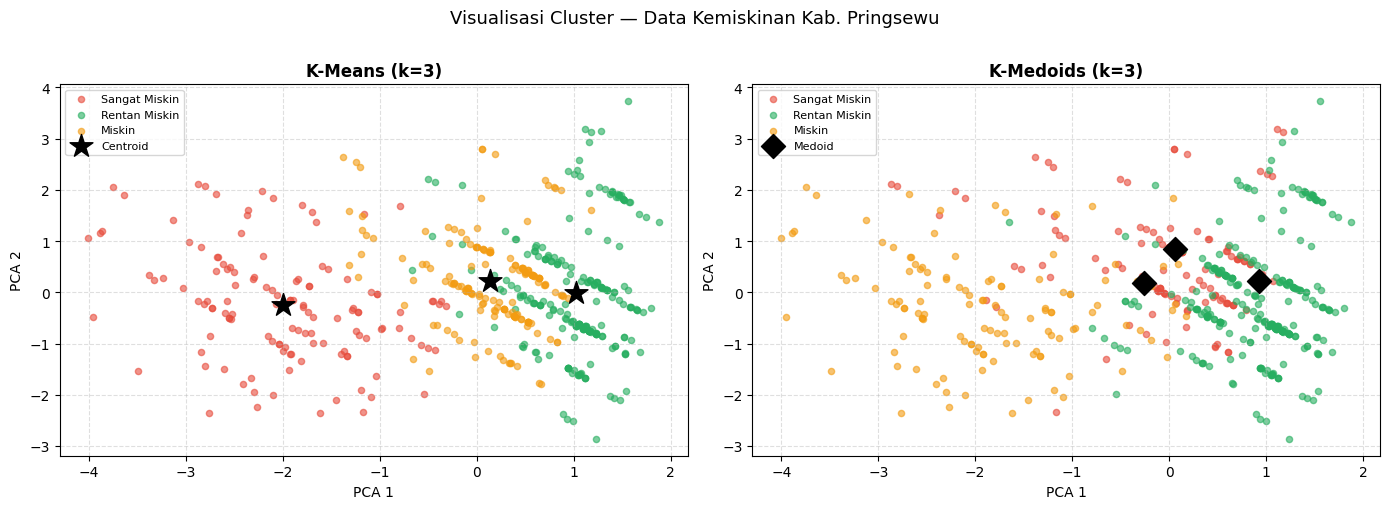

✓ Disimpan ke: /content/output/visualisasi_cluster.png


In [15]:
warna_km   = {'Sangat Miskin': '#E74C3C', 'Miskin': '#F39C12', 'Rentan Miskin': '#27AE60'}
warna_kmed = {'Sangat Miskin': '#E74C3C', 'Miskin': '#F39C12', 'Rentan Miskin': '#27AE60'}

pca  = PCA(n_components=2, random_state=RANDOM_SEED)
X_2d = pca.fit_transform(X_np)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# K-Means scatter
ax = axes[0]
for ci in range(K_CLUSTER):
    nama = km_label_map[ci]
    mask = np.array([l==ci for l in labels_km])
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=warna_km[nama],
               label=nama, alpha=0.6, s=20)
c2d = pca.transform(np.array(centroids_km))
ax.scatter(c2d[:,0], c2d[:,1], marker='*', s=300, c='black', zorder=5, label='Centroid')
ax.set_title(f'K-Means (k={K_CLUSTER})', fontweight='bold', fontsize=12)
ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

# K-Medoids scatter
ax = axes[1]
for ci in range(K_CLUSTER):
    nama = kmed_label_map[ci]
    mask = np.array([l==ci for l in labels_kmed])
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=warna_kmed[nama],
               label=nama, alpha=0.6, s=20)
ax.scatter(X_2d[medoid_idx,0], X_2d[medoid_idx,1],
           marker='D', s=150, c='black', zorder=5, label='Medoid')
ax.set_title(f'K-Medoids (k={K_CLUSTER})', fontweight='bold', fontsize=12)
ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Visualisasi Cluster — Data Kemiskinan Kab. Pringsewu', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/visualisasi_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Disimpan ke: {OUTPUT_DIR}/visualisasi_cluster.png")


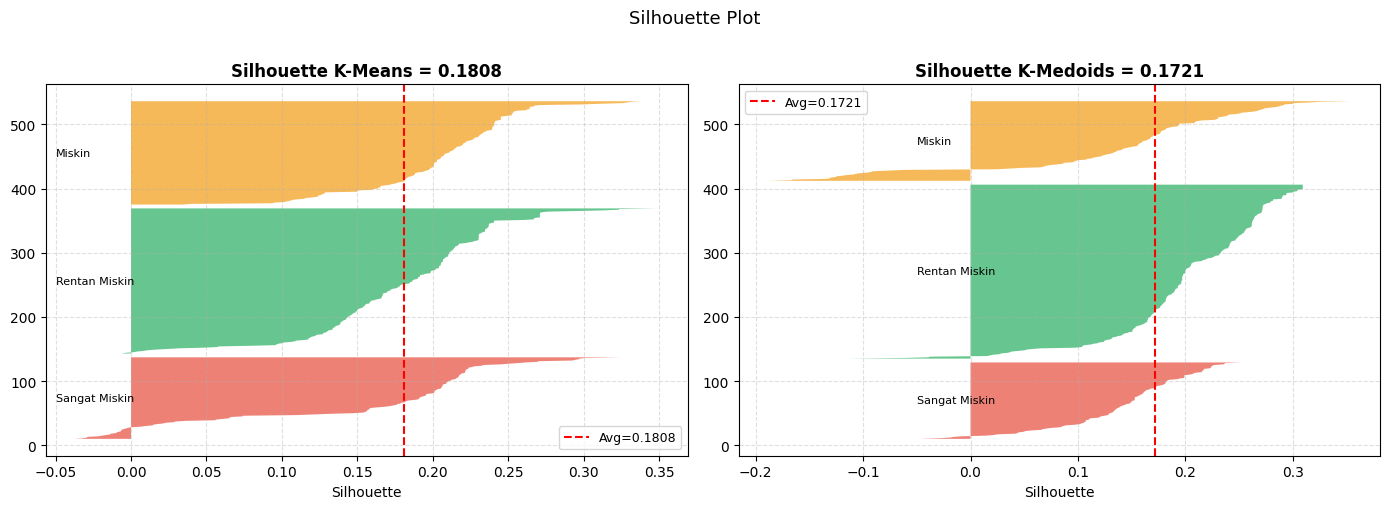

In [16]:
# Silhouette plot
warna_list = {'Sangat Miskin': '#E74C3C', 'Miskin': '#F39C12', 'Rentan Miskin': '#27AE60'}

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, samp, labels, label_map, judul, sil_val in [
    (axes[0], sil_samp_km,   labels_km,   km_label_map,   f'Silhouette K-Means = {sil_km:.4f}',   sil_km),
    (axes[1], sil_samp_kmed, labels_kmed, kmed_label_map, f'Silhouette K-Medoids = {sil_kmed:.4f}', sil_kmed),
]:
    y_lo = 10
    for ci in range(K_CLUSTER):
        nama  = label_map[ci]
        vals  = sorted([samp[i] for i in range(n) if labels[i]==ci])
        y_hi  = y_lo + len(vals)
        ax.fill_betweenx(range(y_lo,y_hi), 0, vals, facecolor=warna_list[nama], alpha=0.7)
        ax.text(-0.05, y_lo+len(vals)/2, nama, fontsize=8, va='center')
        y_lo  = y_hi + 5
    ax.axvline(sil_val, color='red', linestyle='--', label=f'Avg={sil_val:.4f}')
    ax.set_title(judul, fontweight='bold'); ax.set_xlabel('Silhouette')
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle('Silhouette Plot', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()


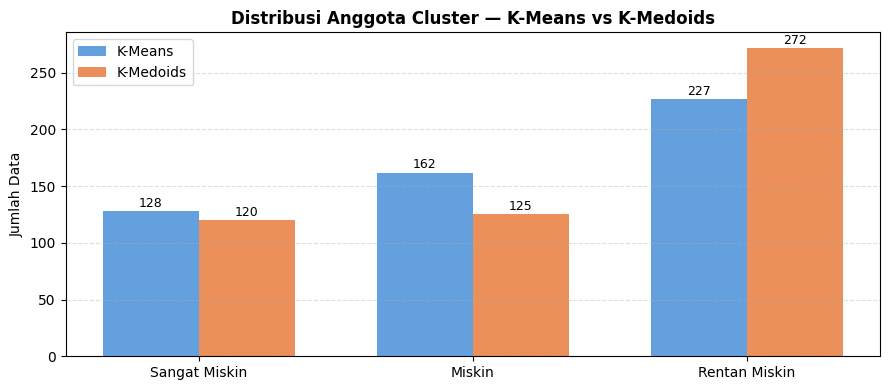

✓ Semua visualisasi tersimpan di /content/output/


In [17]:
# Bar chart distribusi
warna_bar = ['#E74C3C','#F39C12','#27AE60']  # Sangat Miskin, Miskin, Rentan Miskin

# Urutkan label kemiskinan secara konsisten
urutan_label = ['Sangat Miskin', 'Miskin', 'Rentan Miskin']

# Hitung jumlah per kategori untuk K-Means dan K-Medoids
cnt_km   = [sum(1 for l in labels_km   if km_label_map[l]   == lbl) for lbl in urutan_label]
cnt_kmed = [sum(1 for l in labels_kmed if kmed_label_map[l] == lbl) for lbl in urutan_label]

fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(urutan_label)); w = 0.35
b1 = ax.bar(x-w/2, cnt_km,   w, label='K-Means',   color='#4A90D9', alpha=0.85)
b2 = ax.bar(x+w/2, cnt_kmed, w, label='K-Medoids', color='#E87D3E', alpha=0.85)
for bar in b1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                       str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
for bar in b2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                       str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(urutan_label)
ax.set_ylabel('Jumlah Data')
ax.set_title('Distribusi Anggota Cluster — K-Means vs K-Medoids', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribusi_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Semua visualisasi tersimpan di {OUTPUT_DIR}/")


---
## 14. Simpan Semua Hasil ke CSV


In [18]:
# ── Bangun df_hasil dengan semua kolom ──
df_hasil = df_enc.copy()

# Cluster langsung pakai nama tingkat kemiskinan
df_hasil['Cluster_KMeans']        = [km_label_map[l]   for l in labels_km]
df_hasil['Cluster_KMedoids']      = [kmed_label_map[l] for l in labels_kmed]
df_hasil['Silhouette_KMeans']     = [round(s, 4) for s in sil_samp_km]
df_hasil['Silhouette_KMedoids']   = [round(s, 4) for s in sil_samp_kmed]
for ci in range(K_CLUSTER):
    df_hasil[f'Jarak_KMeans_C{ci+1}']   = [round(jarak_km[i][ci],   4) for i in range(n)]
    df_hasil[f'Jarak_KMedoids_M{ci+1}'] = [round(jarak_kmed[i][ci], 4) for i in range(n)]

# Label centroid/medoid untuk CSV pakai nama kemiskinan
urutan_label = ['Sangat Miskin', 'Miskin', 'Rentan Miskin']

# Centroid K-Means: urutkan berdasarkan nama kemiskinan
centroid_rows = []
for ci in range(K_CLUSTER):
    row = dict(zip(KOLOM_FITUR, [round(v,4) for v in centroids_km[ci]]))
    row['Cluster'] = km_label_map[ci]
    centroid_rows.append(row)
df_centroid = pd.DataFrame(centroid_rows)[['Cluster'] + KOLOM_FITUR]

# Medoid K-Medoids: urutkan berdasarkan nama kemiskinan
medoid_rows = []
for ci in range(K_CLUSTER):
    row = dict(zip(KOLOM_FITUR, X[medoid_idx[ci]]))
    row['Cluster']      = kmed_label_map[ci]
    row['Indeks_Data']  = medoid_idx[ci]
    medoid_rows.append(row)
df_medoid = pd.DataFrame(medoid_rows)[['Cluster', 'Indeks_Data'] + KOLOM_FITUR]

# ── Definisi semua file output ──
paths = {
    '02_hasil_clustering.csv'      : df_hasil,
    '03a_log_iterasi_kmeans.csv'   : pd.DataFrame(log_km),
    '03b_log_iterasi_kmedoids.csv' : pd.DataFrame(log_kmed),
    '03c_centroid_kmeans.csv'      : df_centroid,
    '03d_medoid_kmedoids.csv'      : df_medoid,
    '04_perhitungan_manual.csv'    : df_manual,
    '05_perbandingan_akhir.csv'    : pd.DataFrame([
        {'Metode':'K-Means',   'Silhouette': round(sil_km,   4),
         'Interpretasi': interpretasi_silhouette(sil_km),   'Iterasi': len(log_km)},
        {'Metode':'K-Medoids', 'Silhouette': round(sil_kmed, 4),
         'Interpretasi': interpretasi_silhouette(sil_kmed), 'Iterasi': len(log_kmed)},
    ]),
}

# ── Simpan file utama ──
print("=== Menyimpan File Utama ===")
for nama, df_out in paths.items():
    p = f'{OUTPUT_DIR}/{nama}'
    df_out.to_csv(p, index=False)
    print(f"  ✓ {p}")

# ── Simpan data per kategori kemiskinan ──
print("\n=== Menyimpan Data per Kategori Kemiskinan ===")
for metode, kolom_cluster in [('kmeans', 'Cluster_KMeans'), ('kmedoids', 'Cluster_KMedoids')]:
    for label in ['Sangat Miskin', 'Miskin', 'Rentan Miskin']:
        df_filtered = df_hasil[df_hasil[kolom_cluster] == label].copy()
        if len(df_filtered) == 0:
            continue
        fname = f'{OUTPUT_DIR}/{metode}_{label.replace(" ", "_").lower()}.csv'
        df_filtered.to_csv(fname, index=False)
        print(f"  ✓ [{metode.upper()}] {label}: {len(df_filtered)} data → {fname}")

print("\n✓ Semua file berhasil disimpan!")


=== Menyimpan File Utama ===
  ✓ /content/output/02_hasil_clustering.csv
  ✓ /content/output/03a_log_iterasi_kmeans.csv
  ✓ /content/output/03b_log_iterasi_kmedoids.csv
  ✓ /content/output/03c_centroid_kmeans.csv
  ✓ /content/output/03d_medoid_kmedoids.csv
  ✓ /content/output/04_perhitungan_manual.csv
  ✓ /content/output/05_perbandingan_akhir.csv

=== Menyimpan Data per Kategori Kemiskinan ===
  ✓ [KMEANS] Sangat Miskin: 128 data → /content/output/kmeans_sangat_miskin.csv
  ✓ [KMEANS] Miskin: 162 data → /content/output/kmeans_miskin.csv
  ✓ [KMEANS] Rentan Miskin: 227 data → /content/output/kmeans_rentan_miskin.csv
  ✓ [KMEDOIDS] Sangat Miskin: 120 data → /content/output/kmedoids_sangat_miskin.csv
  ✓ [KMEDOIDS] Miskin: 125 data → /content/output/kmedoids_miskin.csv
  ✓ [KMEDOIDS] Rentan Miskin: 272 data → /content/output/kmedoids_rentan_miskin.csv

✓ Semua file berhasil disimpan!


---
## 15. Ringkasan Akhir — Perbandingan K-Means vs K-Medoids

In [19]:
print("=" * 65)
print("  RINGKASAN PERBANDINGAN K-MEANS vs K-MEDOIDS")
print("=" * 65)

print("\n[K-MEANS]")
for ci in range(K_CLUSTER):
    nama = km_label_map[ci]
    print(f"  {nama}: {labels_km.count(ci):4d} data | "
          f"Centroid = {[round(v,3) for v in centroids_km[ci]]}")
print(f"  Iterasi          : {len(log_km)}")
print(f"  Silhouette Score : {sil_km:.4f}  → {interpretasi_silhouette(sil_km)}")

print("\n[K-MEDOIDS]")
for ci in range(K_CLUSTER):
    nama = kmed_label_map[ci]
    print(f"  {nama}: {labels_kmed.count(ci):4d} data | "
          f"Medoid = D{medoid_idx[ci]+1} = {X[medoid_idx[ci]]}")
print(f"  Iterasi          : {len(log_kmed)}")
print(f"  Silhouette Score : {sil_kmed:.4f}  → {interpretasi_silhouette(sil_kmed)}")

print("\n" + "=" * 65)
pemenang = 'K-Means' if sil_km >= sil_kmed else 'K-Medoids'
print(f"  ► Metode terbaik : {pemenang}")
print(f"  ► Selisih Silhouette : {abs(sil_km-sil_kmed):.4f}")
print("=" * 65)
print(f"\n  Output tersimpan di: {OUTPUT_DIR}/")

# Tampilkan tabel perbandingan
pd.DataFrame([
    {'Aspek':'Centroid/Medoid','K-Means':'Rata-rata anggota (bisa bukan data asli)',
     'K-Medoids':'Data asli dalam cluster'},
    {'Aspek':'Update pusat','K-Means':'AVERAGEIF / rata-rata','K-Medoids':'Cek penggantian biaya minimum'},
    {'Aspek':'Ketahanan outlier','K-Means':'Kurang tahan','K-Medoids':'Lebih tahan'},
    {'Aspek':'Jumlah iterasi','K-Means':len(log_km),'K-Medoids':len(log_kmed)},
    {'Aspek':'Silhouette Score','K-Means':round(sil_km,4),'K-Medoids':round(sil_kmed,4)},
    {'Aspek':'Interpretasi','K-Means':interpretasi_silhouette(sil_km),
     'K-Medoids':interpretasi_silhouette(sil_kmed)},
    {'Aspek':'Metode terbaik','K-Means':'✓' if sil_km>=sil_kmed else '','K-Medoids':'✓' if sil_kmed>sil_km else ''},
]).set_index('Aspek')


  RINGKASAN PERBANDINGAN K-MEANS vs K-MEDOIDS

[K-MEANS]
  Sangat Miskin:  128 data | Centroid = [2.43, 2.289, 2.969, 1.922, 2.797, 0.742, 1.203, 3.508, 1.156]
  Rentan Miskin:  227 data | Centroid = [2.639, 2.361, 2.943, 1.996, 4.018, 0.921, 1.529, 3.907, 3.965]
  Miskin:  162 data | Centroid = [2.537, 2.414, 2.926, 1.994, 1.938, 0.796, 1.259, 3.877, 3.889]
  Iterasi          : 12
  Silhouette Score : 0.1808  → Tidak ada struktur cluster yang nyata

[K-MEDOIDS]
  Sangat Miskin:  120 data | Medoid = D147 = [3, 3, 3, 2, 2, 1, 0, 4, 4]
  Rentan Miskin:  272 data | Medoid = D25 = [3, 3, 3, 2, 3, 1, 2, 4, 4]
  Miskin:  125 data | Medoid = D407 = [3, 3, 3, 2, 2, 1, 2, 4, 3]
  Iterasi          : 100
  Silhouette Score : 0.1721  → Tidak ada struktur cluster yang nyata

  ► Metode terbaik : K-Means
  ► Selisih Silhouette : 0.0087

  Output tersimpan di: /content/output/


,K-Means,K-Medoids
Aspek,,
Centroid/Medoid,Rata-rata anggota (bisa bukan data asli),Data asli dalam cluster
Update pusat,AVERAGEIF / rata-rata,Cek penggantian biaya minimum
Ketahanan outlier,Kurang tahan,Lebih tahan
Jumlah iterasi,12,100
Silhouette Score,0.1808,0.1721
Interpretasi,Tidak ada struktur cluster yang nyata,Tidak ada struktur cluster yang nyata
Metode terbaik,✓,
